# Sesión 4: Introducción a Predicción y Causalidad
## Script Práctico — Ecuación de Mincer con ENAHO 2021–2024

**Programa:** IA Generativa Aplicada a Ciencias Sociales y Gestión Pública  
**Sesión:** 4 — Predicción y Causalidad

**Pregunta:** ¿Cuánto aumenta el ingreso laboral por cada año adicional de educación, controlando por características del trabajador?

```
log(ingreso) = β₀ + β₁·años_educ + β₂·edad + β₃·mujer + β₄·urbano + β₅·región + β₆·tam_empresa + ε
```

---
### Módulos utilizados

| Módulo | Archivo | Variables clave |
|--------|---------|----------------|
| 500 — Empleo e Ingresos | `Enaho01a-YYYY-500.csv` | `I524A1`, `I538A1`, `P512A` |
| 300 — Educación | `Enaho01A-YYYY-300.csv` | `P301A`, `P301B` |
| 200 — Características del hogar | `Enaho01-YYYY-200.csv` | `P207`, `P208A`, `ESTRATO`, `DOMINIO` |

> `ESTRATO` y `DOMINIO` vienen en el Módulo 200 — no se necesita la Sumaria.

---
## Bloque 0 — Montar Drive e importar librerías

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import os

pd.set_option('display.float_format', '{:,.3f}'.format)

In [ ]:
RUTA_DATA   = '/content/drive/MyDrive/2026-0/QLAB/DATA/IN/IN/'
RUTA_OUTPUT = '/content/drive/MyDrive/2026-0/QLAB/DATA2/OUT/'
os.makedirs(RUTA_OUTPUT, exist_ok=True)

print(f"Datos   : {RUTA_DATA}")
print(f"Outputs : {RUTA_OUTPUT}")

Datos   : /content/drive/MyDrive/2026-0/QLAB/DATA/IN/IN/
Outputs : /content/drive/MyDrive/2026-0/QLAB/DATA2/OUT/


---
## Bloque 1 — Cargar módulos ENAHO 2024

In [ ]:
eco = pd.read_csv(RUTA_DATA + 'ECO_2024_Enaho01a-2024-500.csv', sep=',', encoding='latin-1', low_memory=False)
edu = pd.read_csv(RUTA_DATA + 'EDU_2024_Enaho01A-2024-300.csv', sep=',', encoding='latin-1', low_memory=False)
dem = pd.read_csv(RUTA_DATA + 'CSE_2024_Enaho01-2024-200.csv',  sep=',', encoding='latin-1', low_memory=False)

print(f"eco : {eco.shape}")
print(f"edu : {edu.shape}")
print(f"dem : {dem.shape}")

eco : (85992, 1425)
edu : (106619, 495)
dem : (117721, 40)


---
## Bloque 2 — Selección de variables por módulo

### 2.1 Módulo 500 — Ingresos y Tamaño de Empresa

| Variable | Descripción | Missing |
|----------|-------------|--------|
| `I524A1` | Ingreso ocupación principal (imputado, deflactado, anualizado) | 999999 |
| `I538A1` | Ingreso ocupación secundaria (imputado, deflactado, anualizado) | 999999 |
| `P512A`  | Tamaño de empresa | 6, 9 = missing |

In [ ]:
COLS_ECO = [
    'CONGLOME', 'VIVIENDA', 'HOGAR', 'CODPERSO',
    'I524A1',   # ingreso ocupación principal (deflactado y anualizado)
    'I538A1',   # ingreso ocupación secundaria (deflactado y anualizado)
    'P512A',    # tamaño de empresa
]

eco_sel = eco[COLS_ECO].copy()
print(f"eco reducido: {eco_sel.shape}")

# Ingresos: 999999 = missing del INEI
for col in ['I524A1', 'I538A1']:
    eco_sel[col] = pd.to_numeric(eco_sel[col], errors='coerce')
    eco_sel[col] = eco_sel[col].replace(999999, np.nan)

# Tamaño empresa: 6 = otro empleador, 9 = no especificado → missing
eco_sel['P512A'] = pd.to_numeric(eco_sel['P512A'], errors='coerce')
eco_sel['P512A'] = eco_sel['P512A'].replace([6, 9], np.nan)

resumen = pd.DataFrame({
    'dtype'   : eco_sel.dtypes,
    'missings': eco_sel.isnull().sum(),
    'pct_miss': (eco_sel.isnull().sum() / len(eco_sel) * 100).round(2)
})
print(resumen)

eco reducido: (85992, 7)
            dtype  missings  pct_miss
CONGLOME    int64         0     0.000
VIVIENDA    int64         0     0.000
HOGAR       int64         0     0.000
CODPERSO    int64         0     0.000
I524A1    float64     60662    70.540
I538A1    float64     82684    96.150
P512A     float64     23342    27.140


### 2.2 Módulo 300 — Educación

| Variable | Descripción | Missing |
|----------|-------------|--------|
| `P301A`  | Último nivel educativo aprobado (1–12) | 99 |
| `P301B`  | Último año aprobado dentro del nivel | 99 |

In [ ]:
COLS_EDU = [
    'CONGLOME', 'VIVIENDA', 'HOGAR', 'CODPERSO',
    'P301A',   # nivel educativo
    'P301B',   # año dentro del nivel
]

edu_sel = edu[COLS_EDU].copy()
print(f"edu reducido: {edu_sel.shape}")

for col in ['P301A', 'P301B']:
    edu_sel[col] = pd.to_numeric(edu_sel[col], errors='coerce')
    edu_sel[col] = edu_sel[col].replace(99, np.nan)

mapa_nivel = {
    1: 'Sin nivel',            2: 'Inicial',
    3: 'Prim. incompleta',     4: 'Prim. completa',
    5: 'Sec. incompleta',      6: 'Sec. completa',
    7: 'Sup. no univ. inc.',   8: 'Sup. no univ. comp.',
    9: 'Sup. univ. inc.',     10: 'Sup. univ. comp.',
   11: 'Maestría/Doctorado',  12: 'Básica especial'
}
print("\nDistribución P301A:")
print(edu_sel['P301A'].value_counts().sort_index().rename(mapa_nivel))

edu reducido: (106619, 6)

Distribución P301A:
P301A
Sin nivel               6440
Inicial                 4801
Prim. incompleta       20492
Prim. completa         11504
Sec. incompleta        16239
Sec. completa          22332
Sup. no univ. inc.      4001
Sup. no univ. comp.     7130
Sup. univ. inc.         5217
Sup. univ. comp.        6877
Maestría/Doctorado      1363
Básica especial          116
Name: count, dtype: int64


### 2.3 Módulo 200 — Características del individuo

| Variable  | Descripción | Categorías / Missing |
|-----------|-------------|--------------------|
| `P207`    | Sexo | 1=Hombre, 2=Mujer |
| `P208A`   | Edad en años cumplidos | Numérica; **99=missing** |
| `ESTRATO` | Estrato geográfico | 1–6=Urbano, 7–8=Rural |
| `DOMINIO` | Dominio geográfico | 1–3=Costa, 4–6=Sierra, 7=Selva, 8=Lima |

> `ESTRATO` y `DOMINIO` están en el Módulo 200 — no se necesita Sumaria.

In [ ]:
COLS_DEM = [
    'CONGLOME', 'VIVIENDA', 'HOGAR', 'CODPERSO',
    'P207',     # sexo
    'P208A',    # edad
    'ESTRATO',  # área urbana/rural
    'DOMINIO',  # región geográfica
]

dem_sel = dem[COLS_DEM].copy()
print(f"dem reducido: {dem_sel.shape}")

dem_sel['P207']    = pd.to_numeric(dem_sel['P207'],    errors='coerce')
dem_sel['P208A']   = pd.to_numeric(dem_sel['P208A'],   errors='coerce').replace(99, np.nan)
dem_sel['ESTRATO'] = pd.to_numeric(dem_sel['ESTRATO'], errors='coerce')
dem_sel['DOMINIO'] = pd.to_numeric(dem_sel['DOMINIO'], errors='coerce')

print(f"\nEdad — rango  : {dem_sel['P208A'].min():.0f} a {dem_sel['P208A'].max():.0f} años")
print(f"Sexo — valores: {sorted(dem_sel['P207'].dropna().unique().astype(int))}")
print(f"ESTRATO       : {sorted(dem_sel['ESTRATO'].dropna().unique().astype(int))}")
print(f"DOMINIO       : {sorted(dem_sel['DOMINIO'].dropna().unique().astype(int))}")

dem reducido: (117721, 8)

Edad — rango  : 0 a 98 años
Sexo — valores: [np.int64(1), np.int64(2)]
ESTRATO       : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
DOMINIO       : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


---
## Bloque 3 — Limpieza: estandarizar llaves de merge

In [ ]:
# Flujo estándar: llave como string homogéneo → crítico para que el merge funcione

# ── 3.1 ECO ───────────────────────────────────────────────
eco_clean = eco_sel.copy()
for col in ['CONGLOME', 'VIVIENDA', 'HOGAR', 'CODPERSO']:
    eco_clean[col] = eco_clean[col].astype(str).str.strip()

# ── 3.2 EDU ───────────────────────────────────────────────
edu_clean = edu_sel.copy()
for col in ['CONGLOME', 'VIVIENDA', 'HOGAR', 'CODPERSO']:
    edu_clean[col] = edu_clean[col].astype(str).str.strip()

# ── 3.3 DEM ───────────────────────────────────────────────
dem_clean = dem_sel.copy()
for col in ['CONGLOME', 'VIVIENDA', 'HOGAR', 'CODPERSO']:
    dem_clean[col] = dem_clean[col].astype(str).str.strip()

# Verificación cruzada
print(f"{'Variable':<12} {'eco':>10} {'edu':>10} {'dem':>10}")
print("-" * 45)
for col in ['CONGLOME', 'VIVIENDA', 'HOGAR', 'CODPERSO']:
    print(f"{col:<12} {str(eco_clean[col].dtype):>10} "
          f"{str(edu_clean[col].dtype):>10} {str(dem_clean[col].dtype):>10}")

Variable            eco        edu        dem
---------------------------------------------
CONGLOME         object     object     object
VIVIENDA         object     object     object
HOGAR            object     object     object
CODPERSO         object     object     object


---
## Bloque 4 — Construir variables de análisis

### 4.1 Variable dependiente: `log_ingreso`

In [ ]:
eco_vars = eco_clean.copy()

# Ingreso total = principal + secundaria
# min_count=1 → NaN solo si AMBAS son NaN
eco_vars['ingreso_total'] = eco_vars[['I524A1', 'I538A1']].sum(axis=1, min_count=1)

# Log del ingreso — Mincer exige ingreso > 0
eco_vars['log_ingreso'] = np.where(
    eco_vars['ingreso_total'] > 0,
    np.log(eco_vars['ingreso_total']),
    np.nan
)

print(eco_vars[['ingreso_total', 'log_ingreso']].describe().round(2))
print(f"\nPersonas con ingreso > 0 : {(eco_vars['ingreso_total'] > 0).sum():,}")
print(f"Personas sin ingreso/NaN : {(~(eco_vars['ingreso_total'] > 0)).sum():,}")

       ingreso_total  log_ingreso
count     27,869.000   27,869.000
mean      19,421.730        9.510
std       17,665.960        0.930
min          121.000        4.800
25%        8,589.000        9.060
50%       14,953.000        9.610
75%       24,160.000       10.090
max      300,181.000       12.610

Personas con ingreso > 0 : 27,869
Personas sin ingreso/NaN : 58,123


### 4.2 Variable de interés: `anios_educ`

| Nivel | Código | Años asignados |
|-------|--------|----------------|
| Sin nivel / Inicial / Básica especial | 1, 2, 12 | 0 |
| Primaria incompleta | 3 | P301B |
| Primaria completa | 4 | 6 |
| Secundaria incompleta | 5 | 6 + P301B |
| Secundaria completa | 6 | 11 |
| Sup. no univ. incompleta | 7 | 11 + P301B |
| Sup. no univ. completa | 8 | 14 |
| Sup. univ. incompleta | 9 | 11 + P301B |
| Sup. univ. completa | 10 | 16 |
| Maestría / Doctorado | 11 | 18 |

In [ ]:
edu_vars = edu_clean.copy()

def calcular_anios_educ(nivel, anio_nivel):
    """Convierte nivel educativo + año dentro del nivel → años de educación acumulados."""
    if pd.isna(nivel):
        return np.nan
    nivel = int(nivel)
    if nivel in [1, 2, 12]:   return 0
    elif nivel == 3:           return anio_nivel if not pd.isna(anio_nivel) else np.nan
    elif nivel == 4:           return 6
    elif nivel == 5:           return 6  + anio_nivel if not pd.isna(anio_nivel) else np.nan
    elif nivel == 6:           return 11
    elif nivel == 7:           return 11 + anio_nivel if not pd.isna(anio_nivel) else np.nan
    elif nivel == 8:           return 14
    elif nivel == 9:           return 11 + anio_nivel if not pd.isna(anio_nivel) else np.nan
    elif nivel == 10:          return 16
    elif nivel == 11:          return 18
    else:                      return np.nan

edu_vars['anios_educ'] = edu_vars.apply(
    lambda r: calcular_anios_educ(r['P301A'], r['P301B']), axis=1
)

print(edu_vars['anios_educ'].describe().round(2))
print(f"\nMissings anios_educ: {edu_vars['anios_educ'].isnull().sum():,}")

count   106,512.000
mean          7.680
std           5.510
min           0.000
25%           0.000
50%           9.000
75%          11.000
max          18.000
Name: anios_educ, dtype: float64

Missings anios_educ: 107


### 4.3 Variables de control — todas desde el Módulo 200

In [ ]:
dem_vars = dem_clean.copy()

# ── edad ──────────────────────────────────────────────────
dem_vars['edad'] = dem_vars['P208A']

# ── mujer: dummy 0=Hombre, 1=Mujer ───────────────────────
dem_vars['mujer'] = np.where(
    dem_vars['P207'].isna(), np.nan,
    (dem_vars['P207'] == 2).astype(float)
)

# ── urbano: 1=Urbano (estratos 1–6), 0=Rural (7–8) ───────
dem_vars['urbano'] = np.where(
    dem_vars['ESTRATO'].isna(), np.nan,
    (dem_vars['ESTRATO'] <= 6).astype(float)
)

# ── region: Lima (ref), Costa, Sierra, Selva ──────────────
mapa_region = {
    1: 'Costa',  2: 'Costa',  3: 'Costa',
    4: 'Sierra', 5: 'Sierra', 6: 'Sierra',
    7: 'Selva',
    8: 'Lima'    # Lima Metropolitana = categoría de referencia
}
dem_vars['region'] = dem_vars['DOMINIO'].map(mapa_region)

# ── tam_empresa: desde eco_clean ──────────────────────────
mapa_tam = {
    1: 'Pequeña',      # 1 trabajador (independiente) — referencia
    2: 'Mediana',      # 2–5
    3: 'Med-grande',   # 6–10
    4: 'Grande',       # 11–50
    5: 'Gran empresa'  # 51+
}
eco_vars['tam_empresa'] = eco_vars['P512A'].map(mapa_tam)

print("mujer:")
print(dem_vars['mujer'].value_counts().rename({0.0: 'Hombre', 1.0: 'Mujer'}))
print("\nurbano:")
print(dem_vars['urbano'].value_counts().rename({0.0: 'Rural', 1.0: 'Urbano'}))
print("\nregion:")
print(dem_vars['region'].value_counts())
print("\ntam_empresa:")
print(eco_vars['tam_empresa'].value_counts())

mujer:
mujer
Mujer     58585
Hombre    55170
Name: count, dtype: int64

urbano:
urbano
Urbano    84249
Rural     33472
Name: count, dtype: int64

region:
region
Sierra    39439
Costa     36113
Selva     28074
Lima      14095
Name: count, dtype: int64

tam_empresa:
tam_empresa
Pequeña         51269
Gran empresa     7485
Mediana          1561
Grande           1387
Med-grande        948
Name: count, dtype: int64


---
## Bloque 5 — Merge y filtros de muestra

```
ETAPA 1: eco_vars + edu_vars  →  nivel persona  (llave CONGLOME+VIVIENDA+HOGAR+CODPERSO)
ETAPA 2: + dem_vars           →  nivel persona  (agrega edad, mujer, urbano, region)
ETAPA 3: Filtros              →  PEA ocupada (ingreso>0), edad>=14, sin missings
```

In [ ]:
LLAVE_PERSONA = ['CONGLOME', 'VIVIENDA', 'HOGAR', 'CODPERSO']

# ── Etapa 1: ECO + EDU ────────────────────────────────────
base = pd.merge(
    eco_vars[LLAVE_PERSONA + ['ingreso_total', 'log_ingreso', 'tam_empresa']],
    edu_vars[LLAVE_PERSONA + ['anios_educ']],
    on=LLAVE_PERSONA, how='inner'
)
print(f"eco_vars : {len(eco_vars):,}")
print(f"+ edu    : {len(base):,}")

# ── Etapa 2: + DEM ────────────────────────────────────────
base = pd.merge(
    base,
    dem_vars[LLAVE_PERSONA + ['edad', 'mujer', 'urbano', 'region']],
    on=LLAVE_PERSONA, how='inner'
)
print(f"+ dem    : {len(base):,}")

eco_vars : 85,992
+ edu    : 85,992
+ dem    : 85,992


In [ ]:
# ── Etapa 3: Filtros de muestra ───────────────────────────
VARS_MODELO = ['log_ingreso', 'anios_educ', 'edad', 'mujer', 'urbano', 'region', 'tam_empresa']

n0 = len(base)

# Filtro 1: PEA ocupada → ingreso positivo
base = base[base['ingreso_total'] > 0].copy()
print(f"Tras filtro ingreso > 0 : {len(base):,}  ({n0 - len(base):,} removidos)")

# Filtro 2: Edad mínima de trabajo
base = base[base['edad'] >= 14].copy()
print(f"Tras filtro edad >= 14  : {len(base):,}")

# Filtro 3: Sin missings en variables del modelo
base = base.dropna(subset=VARS_MODELO).copy()
print(f"Tras eliminar missings  : {len(base):,}")

base['anio'] = 2024
enaho_2024 = base.copy()

print(f"\n✅ enaho_2024: {len(enaho_2024):,} personas | {enaho_2024.shape[1]} variables")
enaho_2024.head()

Tras filtro ingreso > 0 : 27,869  (58,123 removidos)
Tras filtro edad >= 14  : 27,869
Tras eliminar missings  : 27,633

✅ enaho_2024: 27,633 personas | 13 variables


,CONGLOME,VIVIENDA,HOGAR,CODPERSO,ingreso_total,log_ingreso,tam_empresa,anios_educ,edad,mujer,urbano,region,anio
2,15009,47,11,1,"11,267.000",9.330,Grande,14.000,39.000,1.000,1.000,Sierra,2024
3,15009,47,11,2,"6,447.000",8.771,Pequeña,13.000,19.000,1.000,1.000,Sierra,2024
6,15009,71,11,2,"18,255.000",9.812,Gran empresa,14.000,45.000,1.000,1.000,Sierra,2024
7,15009,84,11,1,"26,811.000",10.197,Gran empresa,16.000,30.000,0.000,1.000,Sierra,2024
18,15024,69,11,1,"8,555.000",9.054,Pequeña,12.000,26.000,1.000,1.000,Sierra,2024


---
## Bloque 6 — EDA (Análisis Exploratorio)

### 6.1 Estadísticas descriptivas

In [ ]:
vars_desc = ['log_ingreso', 'ingreso_total', 'anios_educ', 'edad', 'mujer', 'urbano']
print("Estadísticas descriptivas — muestra analítica 2024")
print(enaho_2024[vars_desc].describe().round(2))

Estadísticas descriptivas — muestra analítica 2024
       log_ingreso  ingreso_total  anios_educ       edad      mujer     urbano
count   27,633.000     27,633.000  27,633.000 27,633.000 27,633.000 27,633.000
mean         9.500     19,257.180      11.120     39.160      0.410      0.800
std          0.930     17,612.130       4.380     14.290      0.490      0.400
min          4.800        121.000       0.000     14.000      0.000      0.000
25%          9.050      8,551.000      10.000     27.000      0.000      1.000
50%          9.600     14,757.000      11.000     38.000      0.000      1.000
75%         10.090     24,009.000      14.000     50.000      1.000      1.000
max         12.610    300,181.000      18.000     92.000      1.000      1.000


### 6.2 Distribución del ingreso: antes y después del log

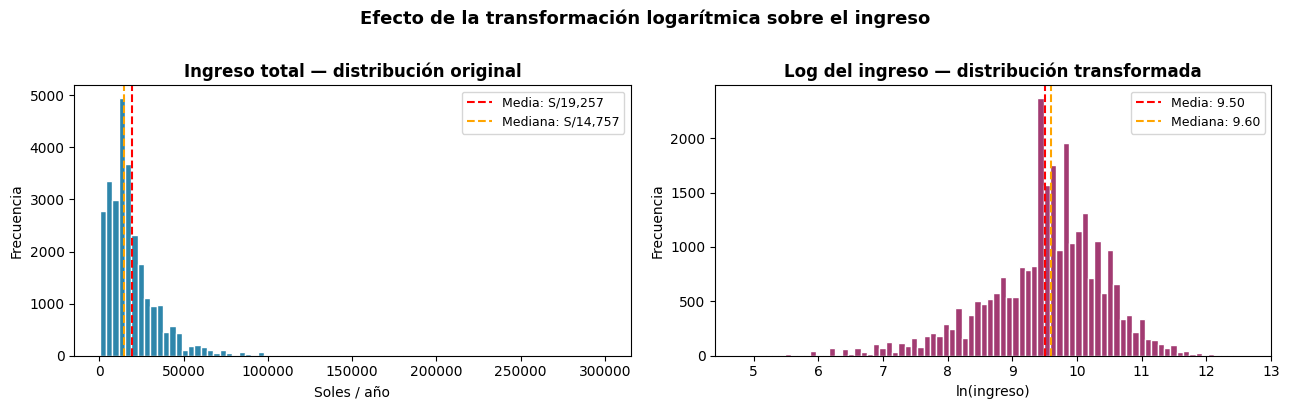

Asimetría original : 3.275
Asimetría log      : -0.816
→ Cuanto más cerca a 0, más simétrica la distribución


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Ingreso original — distribución sesgada
axes[0].hist(enaho_2024['ingreso_total'].dropna(), bins=80, color='#2E86AB', edgecolor='white')
axes[0].set_title('Ingreso total — distribución original', fontweight='bold')
axes[0].set_xlabel('Soles / año')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(enaho_2024['ingreso_total'].mean(),   color='red',    linestyle='--',
                label=f"Media: S/{enaho_2024['ingreso_total'].mean():,.0f}")
axes[0].axvline(enaho_2024['ingreso_total'].median(), color='orange', linestyle='--',
                label=f"Mediana: S/{enaho_2024['ingreso_total'].median():,.0f}")
axes[0].legend(fontsize=9)

# Log del ingreso — distribución más simétrica
axes[1].hist(enaho_2024['log_ingreso'].dropna(), bins=80, color='#A23B72', edgecolor='white')
axes[1].set_title('Log del ingreso — distribución transformada', fontweight='bold')
axes[1].set_xlabel('ln(ingreso)')
axes[1].set_ylabel('Frecuencia')
axes[1].axvline(enaho_2024['log_ingreso'].mean(),   color='red',    linestyle='--',
                label=f"Media: {enaho_2024['log_ingreso'].mean():.2f}")
axes[1].axvline(enaho_2024['log_ingreso'].median(), color='orange', linestyle='--',
                label=f"Mediana: {enaho_2024['log_ingreso'].median():.2f}")
axes[1].legend(fontsize=9)

plt.suptitle('Efecto de la transformación logarítmica sobre el ingreso',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"Asimetría original : {enaho_2024['ingreso_total'].skew():.3f}")
print(f"Asimetría log      : {enaho_2024['log_ingreso'].skew():.3f}")
print("→ Cuanto más cerca a 0, más simétrica la distribución")

### 6.3 Distribución de variables explicativas

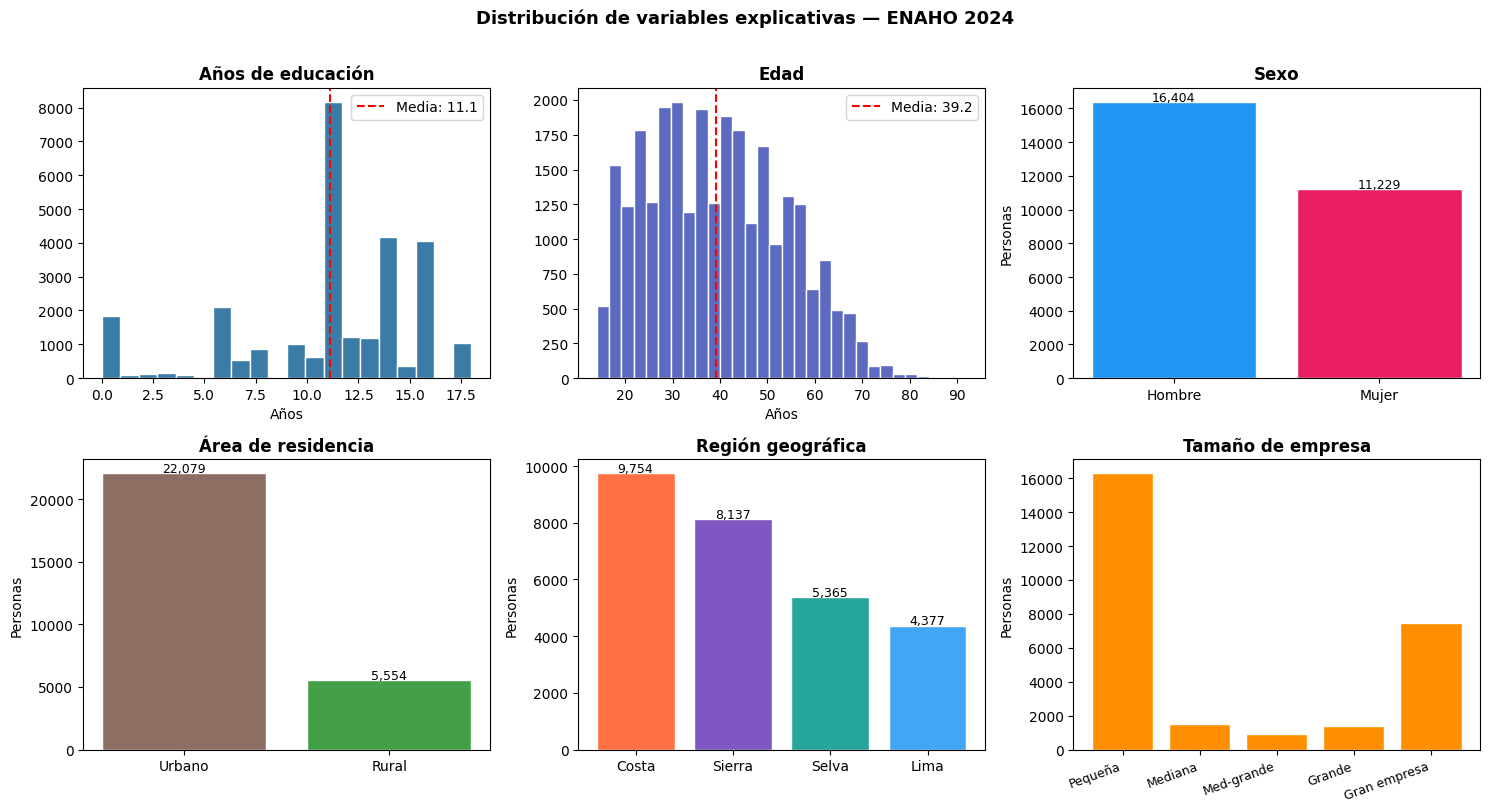

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# ── Años de educación ─────────────────────────────────────
axes[0, 0].hist(enaho_2024['anios_educ'].dropna(), bins=20, color='#3A7CA5', edgecolor='white')
axes[0, 0].set_title('Años de educación', fontweight='bold')
axes[0, 0].set_xlabel('Años')
axes[0, 0].axvline(enaho_2024['anios_educ'].mean(), color='red', linestyle='--',
                   label=f"Media: {enaho_2024['anios_educ'].mean():.1f}")
axes[0, 0].legend()

# ── Edad ──────────────────────────────────────────────────
axes[0, 1].hist(enaho_2024['edad'].dropna(), bins=30, color='#5C6BC0', edgecolor='white')
axes[0, 1].set_title('Edad', fontweight='bold')
axes[0, 1].set_xlabel('Años')
axes[0, 1].axvline(enaho_2024['edad'].mean(), color='red', linestyle='--',
                   label=f"Media: {enaho_2024['edad'].mean():.1f}")
axes[0, 1].legend()

# ── Sexo ──────────────────────────────────────────────────
conteo_sexo = enaho_2024['mujer'].value_counts().rename({0.0: 'Hombre', 1.0: 'Mujer'})
axes[0, 2].bar(conteo_sexo.index, conteo_sexo.values, color=['#2196F3', '#E91E63'], edgecolor='white')
axes[0, 2].set_title('Sexo', fontweight='bold')
axes[0, 2].set_ylabel('Personas')
for i, v in enumerate(conteo_sexo.values):
    axes[0, 2].text(i, v + 50, f'{v:,}', ha='center', fontsize=9)

# ── Urbano/Rural ──────────────────────────────────────────
conteo_urb = enaho_2024['urbano'].value_counts().rename({0.0: 'Rural', 1.0: 'Urbano'})
axes[1, 0].bar(conteo_urb.index, conteo_urb.values, color=['#8D6E63', '#43A047'], edgecolor='white')
axes[1, 0].set_title('Área de residencia', fontweight='bold')
axes[1, 0].set_ylabel('Personas')
for i, v in enumerate(conteo_urb.values):
    axes[1, 0].text(i, v + 50, f'{v:,}', ha='center', fontsize=9)

# ── Región ────────────────────────────────────────────────
conteo_reg = enaho_2024['region'].value_counts()
axes[1, 1].bar(conteo_reg.index, conteo_reg.values,
               color=['#FF7043', '#7E57C2', '#26A69A', '#42A5F5'], edgecolor='white')
axes[1, 1].set_title('Región geográfica', fontweight='bold')
axes[1, 1].set_ylabel('Personas')
for i, (cat, v) in enumerate(conteo_reg.items()):
    axes[1, 1].text(i, v + 50, f'{v:,}', ha='center', fontsize=9)

# ── Tamaño de empresa ─────────────────────────────────────
orden_tam = ['Pequeña', 'Mediana', 'Med-grande', 'Grande', 'Gran empresa']
conteo_tam = enaho_2024['tam_empresa'].value_counts().reindex(orden_tam).fillna(0)
axes[1, 2].bar(range(len(conteo_tam)), conteo_tam.values, color='#FF8F00', edgecolor='white')
axes[1, 2].set_xticks(range(len(conteo_tam)))
axes[1, 2].set_xticklabels(conteo_tam.index, rotation=20, ha='right', fontsize=9)
axes[1, 2].set_title('Tamaño de empresa', fontweight='bold')
axes[1, 2].set_ylabel('Personas')

plt.suptitle('Distribución de variables explicativas — ENAHO 2024',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(RUTA_OUTPUT + 'eda_variables_2024.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Bloque 7 — Función para 2021–2023 + Append

Todo el flujo de los bloques 1–5 encapsulado en una función.  
Un cambio en la lógica → aplica automáticamente a todos los años.

In [ ]:
# ── Nombres de archivos por año ───────────────────────────
# Ajusta si los nombres difieren en tu Drive
ARCHIVOS = {
    2021: {
        'eco': 'ECO_2021_Enaho01a-2021-500.csv',
        'edu': 'EDU_2021_Enaho01a-2021-300.csv',
        'dem': 'CSE_2021_Enaho01-2021-200.csv',
    },
    2022: {
        'eco': 'ECO_2022_Enaho01a-2022-500.csv',
        'edu': 'EDU_2022_Enaho01a-2022-300.csv',
        'dem': 'CSE_2022_Enaho01-2022-200.csv',
    },
    2023: {
        'eco': 'ECO_2023_Enaho01a-2023-500.csv',
        'edu': 'EDU_2023_Enaho01A-2023-300.csv',
        'dem': 'CSE_2023_Enaho01-2023-200.csv',
    },
}
print("✅ Diccionario de archivos definido")

✅ Diccionario de archivos definido


In [ ]:
def procesar_anio_enaho(anio):
    """Carga, limpia y construye variables Mincer para un año de ENAHO.
    Retorna un DataFrame a nivel persona con las variables del modelo.
    """
    print(f"\n{'='*50}")
    print(f"  Procesando ENAHO {anio}")
    print(f"{'='*50}")

    # ── Cargar ────────────────────────────────────────────
    eco_ = pd.read_csv(RUTA_DATA + ARCHIVOS[anio]['eco'], sep=',', encoding='latin-1', low_memory=False)
    edu_ = pd.read_csv(RUTA_DATA + ARCHIVOS[anio]['edu'], sep=',', encoding='latin-1', low_memory=False)
    dem_ = pd.read_csv(RUTA_DATA + ARCHIVOS[anio]['dem'], sep=',', encoding='latin-1', low_memory=False)
    print(f"  ✅ eco={eco_.shape} | edu={edu_.shape} | dem={dem_.shape}")

    # ── Seleccionar columnas disponibles ──────────────────
    eco_ = eco_[[c for c in COLS_ECO if c in eco_.columns]].copy()
    edu_ = edu_[[c for c in COLS_EDU if c in edu_.columns]].copy()
    dem_ = dem_[[c for c in COLS_DEM if c in dem_.columns]].copy()

    # ── Estandarizar llaves ───────────────────────────────
    for df_ in [eco_, edu_, dem_]:
        for col in ['CONGLOME', 'VIVIENDA', 'HOGAR', 'CODPERSO']:
            if col in df_.columns:
                df_[col] = df_[col].astype(str).str.strip()

    # ── Tipos y missings ──────────────────────────────────
    for col in ['I524A1', 'I538A1']:
        if col in eco_.columns:
            eco_[col] = pd.to_numeric(eco_[col], errors='coerce').replace(999999, np.nan)
    eco_['P512A'] = pd.to_numeric(eco_['P512A'], errors='coerce').replace([6, 9], np.nan)

    for col in ['P301A', 'P301B']:
        edu_[col] = pd.to_numeric(edu_[col], errors='coerce').replace(99, np.nan)

    dem_['P207']    = pd.to_numeric(dem_['P207'],    errors='coerce')
    dem_['P208A']   = pd.to_numeric(dem_['P208A'],   errors='coerce').replace(99, np.nan)
    dem_['ESTRATO'] = pd.to_numeric(dem_['ESTRATO'], errors='coerce')
    dem_['DOMINIO'] = pd.to_numeric(dem_['DOMINIO'], errors='coerce')

    # ── Construir variables ───────────────────────────────
    eco_['ingreso_total'] = eco_[['I524A1', 'I538A1']].sum(axis=1, min_count=1)
    eco_['log_ingreso']   = np.where(eco_['ingreso_total'] > 0,
                                     np.log(eco_['ingreso_total']), np.nan)
    eco_['tam_empresa']   = eco_['P512A'].map(mapa_tam)

    edu_['anios_educ'] = edu_.apply(
        lambda r: calcular_anios_educ(r['P301A'], r['P301B']), axis=1
    )

    # Todo desde el Módulo 200
    dem_['edad']   = dem_['P208A']
    dem_['mujer']  = np.where(dem_['P207'].isna(), np.nan,
                              (dem_['P207'] == 2).astype(float))
    dem_['urbano'] = np.where(dem_['ESTRATO'].isna(), np.nan,
                              (dem_['ESTRATO'] <= 6).astype(float))
    dem_['region'] = dem_['DOMINIO'].map(mapa_region)

    # ── Merge ─────────────────────────────────────────────
    LLAVE_P = ['CONGLOME', 'VIVIENDA', 'HOGAR', 'CODPERSO']

    base = pd.merge(
        eco_[LLAVE_P + ['ingreso_total', 'log_ingreso', 'tam_empresa']],
        edu_[LLAVE_P + ['anios_educ']],
        on=LLAVE_P, how='inner'
    )
    base = pd.merge(
        base,
        dem_[LLAVE_P + ['edad', 'mujer', 'urbano', 'region']],
        on=LLAVE_P, how='inner'
    )

    # ── Filtros de muestra ────────────────────────────────
    base = base[base['ingreso_total'] > 0].copy()
    base = base[base['edad'] >= 14].copy()
    base = base.dropna(subset=VARS_MODELO).copy()
    base['anio'] = anio

    print(f"  ✅ muestra_{anio}: {len(base):,} personas | {base.shape[1]} variables")
    return base

In [ ]:
# ── Procesar años 2021–2023 ───────────────────────────────
enaho_2023 = procesar_anio_enaho(2023)
enaho_2022 = procesar_anio_enaho(2022)
enaho_2021 = procesar_anio_enaho(2021)


  Procesando ENAHO 2023
  ✅ eco=(86654, 1414) | edu=(108354, 511) | dem=(119747, 40)
  ✅ muestra_2023: 27,505 personas | 13 variables

  Procesando ENAHO 2022
  ✅ eco=(87661, 1445) | edu=(110257, 511) | dem=(121253, 40)
  ✅ muestra_2022: 28,032 personas | 13 variables

  Procesando ENAHO 2021
  ✅ eco=(86806, 1459) | edu=(109867, 513) | dem=(121067, 41)
  ✅ muestra_2021: 25,899 personas | 13 variables


In [ ]:
# ── Append 2021–2024 ─────────────────────────────────────
enaho_panel = pd.concat(
    [enaho_2021, enaho_2022, enaho_2023, enaho_2024],
    ignore_index=True
)

print("Panel ENAHO 2021–2024:")
print(f"  Total personas : {len(enaho_panel):,}")
print(f"  Columnas       : {enaho_panel.shape[1]}")
print()
print("Personas por año:")
print(enaho_panel['anio'].value_counts().sort_index())

Panel ENAHO 2021–2024:
  Total personas : 109,069
  Columnas       : 13

Personas por año:
anio
2021    25899
2022    28032
2023    27505
2024    27633
Name: count, dtype: int64


---
## Bloque 8 — Regresiones univariadas

Antes del modelo completo, exploramos la relación de cada variable con `log_ingreso` por separado.

> **Interpretación:** en un modelo log-nivel, β ≈ cambio porcentual en el ingreso ante +1 unidad en X  
> Exactamente: %Δingreso = (e^β − 1) × 100

In [ ]:
# Definir categorías de referencia
enaho_panel['region']      = pd.Categorical(
    enaho_panel['region'],      categories=['Lima', 'Costa', 'Sierra', 'Selva'])
enaho_panel['tam_empresa'] = pd.Categorical(
    enaho_panel['tam_empresa'], categories=['Pequeña', 'Mediana', 'Med-grande', 'Grande', 'Gran empresa'])

print("Referencia región     : Lima")
print("Referencia tam_empresa: Pequeña")

Referencia región     : Lima
Referencia tam_empresa: Pequeña


In [ ]:
m1 = smf.ols('log_ingreso ~ anios_educ', data=enaho_panel).fit()
print("=" * 55)
print("M1: log_ingreso ~ anios_educ")
print("=" * 55)
print(m1.summary().tables[1])
print(f"R² = {m1.rsquared:.4f} | N = {int(m1.nobs):,}")

M1: log_ingreso ~ anios_educ
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      8.2509      0.007   1193.211      0.000       8.237       8.264
anios_educ     0.1048      0.001    179.171      0.000       0.104       0.106
R² = 0.2274 | N = 109,069


In [ ]:
m2 = smf.ols('log_ingreso ~ mujer', data=enaho_panel).fit()
print("=" * 55)
print("M2: log_ingreso ~ mujer")
print("=" * 55)
print(m2.summary().tables[1])
print(f"R² = {m2.rsquared:.4f} | N = {int(m2.nobs):,}")

M2: log_ingreso ~ mujer
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      9.4511      0.004   2491.400      0.000       9.444       9.458
mujer         -0.1295      0.006    -21.540      0.000      -0.141      -0.118
R² = 0.0042 | N = 109,069


In [ ]:
m3 = smf.ols('log_ingreso ~ edad', data=enaho_panel).fit()
print("=" * 55)
print("M3: log_ingreso ~ edad")
print("=" * 55)
print(m3.summary().tables[1])
print(f"R² = {m3.rsquared:.4f} | N = {int(m3.nobs):,}")

M3: log_ingreso ~ edad
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      9.0647      0.008   1068.922      0.000       9.048       9.081
edad           0.0086      0.000     42.068      0.000       0.008       0.009
R² = 0.0160 | N = 109,069


In [ ]:
m4 = smf.ols('log_ingreso ~ urbano', data=enaho_panel).fit()
print("=" * 55)
print("M4: log_ingreso ~ urbano")
print("=" * 55)
print(m4.summary().tables[1])
print(f"R² = {m4.rsquared:.4f} | N = {int(m4.nobs):,}")

M4: log_ingreso ~ urbano
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      8.7720      0.006   1430.262      0.000       8.760       8.784
urbano         0.7907      0.007    114.848      0.000       0.777       0.804
R² = 0.1079 | N = 109,069


In [ ]:
m5 = smf.ols('log_ingreso ~ C(region, Treatment("Lima"))', data=enaho_panel).fit()
print("=" * 55)
print("M5: log_ingreso ~ region  (ref = Lima)")
print("=" * 55)
print(m5.summary().tables[1])
print(f"R² = {m5.rsquared:.4f} | N = {int(m5.nobs):,}")

M5: log_ingreso ~ region  (ref = Lima)
                                             coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
Intercept                                  9.7868      0.007   1332.340      0.000       9.772       9.801
C(region, Treatment("Lima"))[T.Costa]     -0.2773      0.009    -31.597      0.000      -0.295      -0.260
C(region, Treatment("Lima"))[T.Sierra]    -0.6216      0.009    -68.723      0.000      -0.639      -0.604
C(region, Treatment("Lima"))[T.Selva]     -0.5387      0.010    -54.744      0.000      -0.558      -0.519
R² = 0.0506 | N = 109,069


In [ ]:
m6 = smf.ols('log_ingreso ~ C(tam_empresa, Treatment("Pequeña"))', data=enaho_panel).fit()
print("=" * 55)
print("M6: log_ingreso ~ tam_empresa  (ref = Pequeña)")
print("=" * 55)
print(m6.summary().tables[1])
print(f"R² = {m6.rsquared:.4f} | N = {int(m6.nobs):,}")

M6: log_ingreso ~ tam_empresa  (ref = Pequeña)
                                                           coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------
Intercept                                                8.9833      0.003   2780.983      0.000       8.977       8.990
C(tam_empresa, Treatment("Pequeña"))[T.Mediana]          0.7439      0.011     65.280      0.000       0.722       0.766
C(tam_empresa, Treatment("Pequeña"))[T.Med-grande]       0.8796      0.014     61.326      0.000       0.852       0.908
C(tam_empresa, Treatment("Pequeña"))[T.Grande]           0.9594      0.012     83.325      0.000       0.937       0.982
C(tam_empresa, Treatment("Pequeña"))[T.Gran empresa]     1.1312      0.006    193.974      0.000       1.120       1.143
R² = 0.2814 | N = 109,069


---
## Bloque 9 — Regresión multivariada (Ecuación de Mincer)

```
log(ingreso) = β₀ + β₁·años_educ + β₂·edad + β₃·mujer
             + β₄·urbano + β₅·región + β₆·tam_empresa + ε
```

Al incluir todos los controles, β₁ refleja el **retorno neto a la educación**  
manteniendo constante el perfil del trabajador.

In [ ]:
formula_mincer = (
    'log_ingreso ~ anios_educ + edad + mujer + urbano '
    '+ C(region, Treatment("Lima")) '
    '+ C(tam_empresa, Treatment("Pequeña"))'
)

m_full = smf.ols(formula_mincer, data=enaho_panel).fit()
print(m_full.summary())

                            OLS Regression Results                            
Dep. Variable:            log_ingreso   R-squared:                       0.424
Model:                            OLS   Adj. R-squared:                  0.424
Method:                 Least Squares   F-statistic:                     7286.
Date:                Sat, 14 Mar 2026   Prob (F-statistic):               0.00
Time:                        18:02:24   Log-Likelihood:            -1.2186e+05
No. Observations:              109069   AIC:                         2.437e+05
Df Residuals:                  109057   BIC:                         2.439e+05
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                                           coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------

### 9.1 Tabla comparativa: univariada vs. Mincer completo

In [ ]:
coef_uni  = m1.params['anios_educ']
coef_full = m_full.params['anios_educ']

print("=" * 60)
print("  Retorno a la educación: univariada vs. Mincer completo")
print("=" * 60)
print(f"  Modelo univariado   | β_educ = {coef_uni:.4f}  | R² = {m1.rsquared:.4f}")
print(f"  Modelo multivariado | β_educ = {coef_full:.4f}  | R² = {m_full.rsquared:.4f}")
print()
print(f"  Diferencia     : {coef_full - coef_uni:+.4f}")
print(f"  Interpretación : un año más de educación aumenta el")
print(f"  ingreso aprox. {coef_full*100:.1f}% controlando por edad, sexo,")
print(f"  área, región y tamaño de empresa.")

In [ ]:
# Tabla resumen de todos los modelos
modelos = {
    'M1: educación': m1,
    'M2: sexo'     : m2,
    'M3: edad'     : m3,
    'M4: urbano'   : m4,
    'M5: región'   : m5,
    'M6: empresa'  : m6,
    'M7: Mincer'   : m_full,
}

resumen_modelos = pd.DataFrame({
    nombre: {
        'N'         : f"{int(mod.nobs):,}",
        'R²'        : round(mod.rsquared, 4),
        'R² ajust.' : round(mod.rsquared_adj, 4),
        'AIC'       : round(mod.aic, 1),
    }
    for nombre, mod in modelos.items()
}).T

print("Resumen de modelos:")
print(resumen_modelos.to_string())

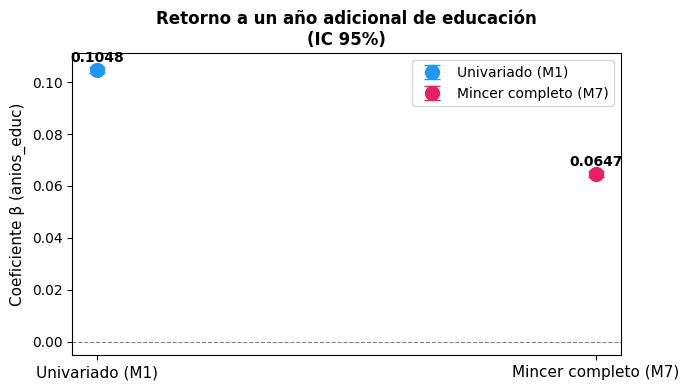

In [ ]:
# Gráfico: coeficiente de anios_educ con IC 95%
fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#2196F3', '#E91E63']
modelos_educ = {'Univariado (M1)': m1, 'Mincer completo (M7)': m_full}

for i, (nombre, mod) in enumerate(modelos_educ.items()):
    coef = mod.params['anios_educ']
    ci   = mod.conf_int().loc['anios_educ']
    ax.errorbar(
        x=[i], y=[coef],
        yerr=[[coef - ci[0]], [ci[1] - coef]],
        fmt='o', markersize=10, capsize=6,
        color=colors[i], label=nombre
    )
    ax.text(i, coef + 0.003, f'{coef:.4f}', ha='center', fontsize=10, fontweight='bold')

ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Univariado (M1)', 'Mincer completo (M7)'], fontsize=11)
ax.set_ylabel('Coeficiente β (anios_educ)', fontsize=11)
ax.set_title('Retorno a un año adicional de educación\n(IC 95%)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(RUTA_OUTPUT + 'coeficiente_educacion.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Bloque 10 — Exportar

In [ ]:
enaho_panel.to_csv(RUTA_OUTPUT + 'enaho_panel_personas_2021_2024.csv',
                   index=False, encoding='utf-8')

with open(RUTA_OUTPUT + 'mincer_resultados.txt', 'w') as f:
    f.write(m_full.summary().as_text())

print("Archivos exportados:")
print(f"  enaho_panel_personas_2021_2024.csv → {len(enaho_panel):,} personas")
print(f"  mincer_resultados.txt              → resultados modelo completo")
print(f"  eda_variables_2024.png             → gráficos EDA")
print(f"  coeficiente_educacion.png          → comparación coeficientes")

Archivos exportados:
  enaho_panel_personas_2021_2024.csv → 109,069 personas
  mincer_resultados.txt              → resultados modelo completo
  eda_variables_2024.png             → gráficos EDA
  coeficiente_educacion.png          → comparación coeficientes


In [ ]:
print("=" * 55)
print("  RESUMEN FINAL — Ecuación de Mincer ENAHO 2021–2024")
print("=" * 55)
print(f"  Personas totales : {len(enaho_panel):,}")
print(f"  Variables        : {enaho_panel.shape[1]}")
print(f"  Años cubiertos   : {sorted(enaho_panel['anio'].unique())}")
print()
print("  Coeficientes clave (Mincer completo):")
print(f"  β educación  = {m_full.params['anios_educ']:.4f}  (p = {m_full.pvalues['anios_educ']:.4f})")
print(f"  β edad       = {m_full.params['edad']:.4f}  (p = {m_full.pvalues['edad']:.4f})")
print(f"  β mujer      = {m_full.params['mujer']:.4f}  (p = {m_full.pvalues['mujer']:.4f})")
print(f"  β urbano     = {m_full.params['urbano']:.4f}  (p = {m_full.pvalues['urbano']:.4f})")
print(f"  R²           = {m_full.rsquared:.4f}")
print(f"  N            = {int(m_full.nobs):,}")

  RESUMEN FINAL — Ecuación de Mincer ENAHO 2021–2024
  Personas totales : 109,069
  Variables        : 13
  Años cubiertos   : [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

  Coeficientes clave (Mincer completo):
  β educación  = 0.0647  (p = 0.0000)
  β edad       = 0.0074  (p = 0.0000)
  β mujer      = -0.2759  (p = 0.0000)
  β urbano     = 0.3068  (p = 0.0000)
  R²           = 0.4236
  N            = 109,069
